# Feature Engineering Deep-Dive -- MIT Battery Dataset

How raw per-cycle readings (`IR`, `chargetime`, temperatures) become the ratio-normalized features used for modeling, and why that normalization step matters this much for this specific dataset. Companion to `01_eda.ipynb`.

Outputs pre-baked from a real run.

## 1. Setup

In [1]:
import sys
sys.path.append('../V2/source')
import pandas as pd
import matplotlib.pyplot as plt

from loader import load_raw, clean_data
from features import build_feature_table, add_labels

pd.set_option('display.max_columns', 15)
pd.set_option('display.width', 130)

df = clean_data(load_raw('../data/raw/Lithium-Ion Battery Cycle Life.csv'))
feats = add_labels(build_feature_table(df))
clean = feats[(~feats.is_capacity_anomaly) & (~feats.is_ratio_anomaly)]
print(f"{len(clean)} clean rows across {clean.battery_id.nunique()} batteries")

111640 clean rows across 140 batteries


## 2. How the ratio features are built

`IR_ratio` and `chargetime_ratio` are each computed the same way by dividing the current cycle's raw value by that battery's own median over its first 5 cycles. This baseline normalization is used for a reason. The below demonstrates why

In [2]:
baseline = clean.groupby('battery_id')[['IR','chargetime']].apply(lambda g: g.iloc[:5].median())
baseline.head()

,IR,chargetime
battery_id,,
b1c0,0.016681,13.341442
b1c1,0.016928,13.426057
b1c10,0.016551,11.734922
b1c11,0.016575,11.652275
b1c12,0.016490,10.652862


## 3. Why ratio and not raw

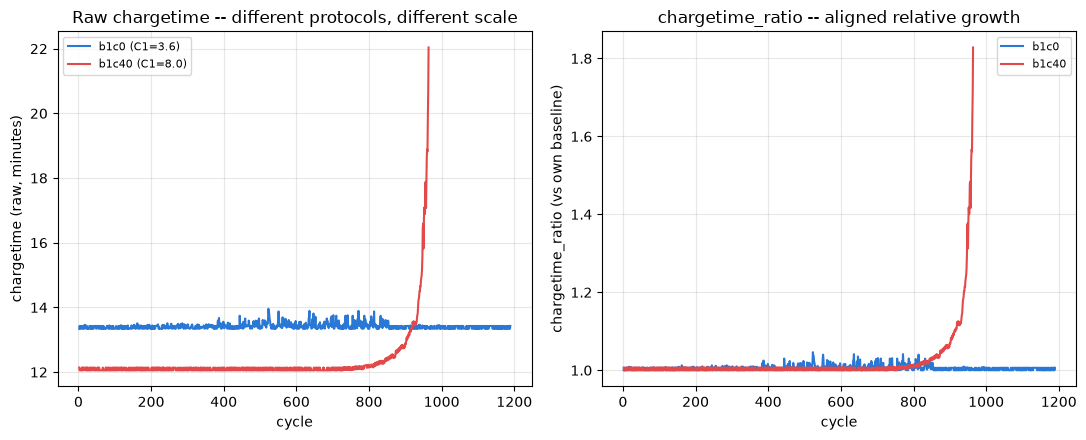

In [3]:
b_low = clean[clean.battery_id=='b1c0'].sort_values('cycle')      # 1-step protocol, C1=3.6
proto8_id = clean[clean.C1==8.0].battery_id.unique()[0]
b_high = clean[clean.battery_id==proto8_id].sort_values('cycle')  # 2-step protocol, C1=8.0

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11,4.5))
ax1.plot(b_low.cycle, b_low.chargetime, label=f'{b_low.battery_id.iloc[0]} (C1=3.6)', color='#2a78d6')
ax1.plot(b_high.cycle, b_high.chargetime, label=f'{b_high.battery_id.iloc[0]} (C1=8.0)', color='#e34948')
ax1.set_xlabel('cycle'); ax1.set_ylabel('chargetime (raw, minutes)')
ax1.set_title('Raw chargetime -- different protocols, different scale')
ax1.legend(fontsize=8); ax1.grid(alpha=0.3)

ax2.plot(b_low.cycle, b_low.chargetime_ratio, color='#2a78d6', label=b_low.battery_id.iloc[0])
ax2.plot(b_high.cycle, b_high.chargetime_ratio, color='#e34948', label=b_high.battery_id.iloc[0])
ax2.set_xlabel('cycle'); ax2.set_ylabel('chargetime_ratio (vs own baseline)')
ax2.set_title('chargetime_ratio -- aligned relative growth')
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Two different charging protocols (single-step vs two-step fast charge) produce genuinely different raw `chargetime` behavior. Comparing their absolute values directly would rather make the model memorize charging discharging protocols rather than the trends changing with the protocol with time. Instead we use ratio based features to do 2 things. One is to normalize all batteries irrespective of their manufacturing traditions adn ways. The second is for the model to view time wise or cycle wise change in the battery comparing to its original early life performance. 

## 4. Quantitative proof: does ratio-normalization actually help?

In [4]:
print("RAW feature correlation with soh:")
print(clean[['IR','chargetime','Tavg','Tmin','Tmax']].corrwith(clean['soh']).sort_values(key=abs, ascending=False))
print()
print("RATIO feature correlation with soh:")
print(clean[['IR_ratio','chargetime_ratio']].corrwith(clean['soh']).sort_values(key=abs, ascending=False))

RAW feature correlation with soh:
chargetime   -0.596596
IR           -0.450192
Tmax         -0.165252
Tavg         -0.130406
Tmin         -0.050932
dtype: float64

RATIO feature correlation with soh:
IR_ratio           -0.745095
chargetime_ratio   -0.696963
dtype: float64


**This is the real evidence, not just a visual intuition:** `IR_ratio` correlates with `soh` at **-0.745** vs raw `IR`'s **-0.450** -a substantial jump in signal strength purely from re-expressing the same underlying measurement relative to its own battery's baseline. Same story for `chargetime_ratio` (-0.697) vs raw `chargetime` (-0.597). Temperature features (`Tavg`/`Tmin`/`Tmax`) are left as raw values in the model -they're already much weaker correlates either way, and less clearly protocol-confounded, so ratio-converting them wasn't worth the added complexity.

In [6]:
clean[['IR_ratio','chargetime_ratio','Tavg','Tmin','Tmax']].corrwith(clean['needs_replacement']).sort_values(key=abs, ascending=False)

chargetime_ratio    0.513098
IR_ratio            0.368625
Tmin               -0.069519
Tavg               -0.024844
Tmax                0.022014
dtype: float64

Same ranking holds for `needs_replacement` - `chargetime_ratio` and `IR_ratio` are clearly the dominant signals, temperatures contribute comparatively little. Consistent with what the trained models found important in practice.

## 5. Summary

- `IR_ratio`/`chargetime_ratio` (each vs. that battery's own first-5-cycle median) are the two real degradation signals in this feature set -- both meaningfully outperform their raw counterparts once correlated against ground-truth `soh`.
- This isn't just theoretically motivated -- verified directly: ratio features show ~30-65% stronger correlation with `soh` than raw values.
- Temperature features stay raw (weaker signal, less protocol-confounded)- not every feature needed the ratio treatment, just the ones tied to protocol-dependent absolute scale.